# Task 1 — Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay

Observation:-

1--> NumPy is used for numerical operations and mathematical calculations.
    
2--> Pandas helps in loading, cleaning, and analyzing structured data.
    
3--> Matplotlib and Seaborn are used for creating visualizations and graphs.
    
4--> Scikit-learn provides machine learning tools such as Logistic Regression and evaluation metrics.

# Task 2 — Load the Dataset

In [4]:
# Load Dataset
df = pd.read_csv('student_exam_performance_dataset.csv')

In [5]:
# First 5 rows
df.head()

,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
0,S00001,Male,17,High School,Medium,Yes,Quiet,2.98,96.5,6.05,...,1,Yes,42.8,62.4,54.8,51.8,49.1,2.44,Fail,F
1,S00002,Female,18,High School,Low,Yes,Quiet,4.45,95.7,6.96,...,0,Yes,77.9,73.5,64.4,61.6,70.1,2.79,Pass,C
2,S00003,Male,17,High School,Medium,No,Quiet,3.75,76.0,7.02,...,4,Yes,53.5,38.3,36.3,47.1,42.2,1.49,Fail,F
3,S00004,Male,18,Bachelor,Medium,Yes,Quiet,2.03,72.6,6.23,...,4,No,28.3,23.5,32.0,39.0,31.9,1.34,Fail,F
4,S00005,Male,18,Bachelor,Medium,Yes,Quiet,5.14,87.3,8.54,...,0,No,74.7,54.9,73.6,55.5,66.4,2.60,Pass,C


Observation:-

1--> The first 5 rows provide an overview of dataset structure and feature values.
    
2--> Both categorical and numerical features are present in the dataset.

In [6]:
# last 5 rows
df.tail()

,student_id,gender,age,parental_education,family_income,internet_access,study_environment,study_hours_per_day,attendance_rate,sleep_hours,...,online_courses_completed,tutoring,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa,pass_fail,grade_category
9995,S09996,Female,15,Master,High,Yes,Moderate,3.80,83.1,7.48,...,1,No,44.2,38.2,38.5,39.0,41.9,1.54,Fail,F
9996,S09997,Male,15,High School,Medium,Yes,Quiet,2.46,68.0,6.76,...,3,No,56.8,46.2,50.6,34.9,47.5,1.49,Fail,F
9997,S09998,Female,15,High School,Low,Yes,Moderate,5.08,76.0,6.90,...,2,No,67.4,50.5,63.7,83.3,64.2,2.38,Pass,D
9998,S09999,Female,18,Bachelor,Medium,Yes,Moderate,1.56,91.0,7.13,...,1,No,35.4,35.5,46.8,47.2,44.3,1.45,Fail,F
9999,S10000,Male,17,High School,Low,Yes,Noisy,3.63,100.0,5.42,...,0,No,66.7,61.6,60.3,60.4,59.6,2.24,Pass,D


Observation:-

1--> The last 5 rows confirm that the dataset has been loaded completely.

In [7]:
# shape of dataset
df.shape

(10000, 23)

Observation:- 

1--> The dataset contains 10000 rows and 23 columns.

In [8]:
# column names
df.columns

Index(['student_id', 'gender', 'age', 'parental_education', 'family_income',
       'internet_access', 'study_environment', 'study_hours_per_day',
       'attendance_rate', 'sleep_hours', 'social_media_hours',
       'assignment_completion_rate', 'participation_score',
       'online_courses_completed', 'tutoring', 'math_score', 'reading_score',
       'writing_score', 'science_score', 'final_exam_score', 'previous_gpa',
       'pass_fail', 'grade_category'],
      dtype='str')

# Questions

1. How many rows and columns are present?

10000 rows and 23 columns

2. What is the target variable?
pass_fail

3. What type of dataset is this?

4. 
Binary Classification Dataset
because the target contains only two classes:
0 → Fail
1 → Pass

Observation:-

1--> The dataset contains both numerical and categorical features.
    
2--> The target column is pass_fail, which is used for prediction.
    
3--> The dataset is structured and suitable for supervised machine learning.
    
4--> Multiple academic and behavioral factors are available for analysis.

# Task 3 — Dataset Understanding

In [14]:
df.columns

Index(['student_id', 'gender', 'age', 'parental_education', 'family_income',
       'internet_access', 'study_environment', 'study_hours_per_day',
       'attendance_rate', 'sleep_hours', 'social_media_hours',
       'assignment_completion_rate', 'participation_score',
       'online_courses_completed', 'tutoring', 'math_score', 'reading_score',
       'writing_score', 'science_score', 'final_exam_score', 'previous_gpa',
       'pass_fail', 'grade_category'],
      dtype='str')

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  10000 non-null  str    
 1   gender                      10000 non-null  str    
 2   age                         10000 non-null  int64  
 3   parental_education          10000 non-null  str    
 4   family_income               10000 non-null  str    
 5   internet_access             10000 non-null  str    
 6   study_environment           10000 non-null  str    
 7   study_hours_per_day         10000 non-null  float64
 8   attendance_rate             10000 non-null  float64
 9   sleep_hours                 10000 non-null  float64
 10  social_media_hours          10000 non-null  float64
 11  assignment_completion_rate  10000 non-null  float64
 12  participation_score         10000 non-null  float64
 13  online_courses_completed    10000 non-null 

Observation:- 

1--> Numerical and categorical columns are present.

2--> Data types are correctly assigned.

3--> Dataset structure is clean and not null value.

In [15]:
df.isnull().sum()

student_id                    0
gender                        0
age                           0
parental_education            0
family_income                 0
internet_access               0
study_environment             0
study_hours_per_day           0
attendance_rate               0
sleep_hours                   0
social_media_hours            0
assignment_completion_rate    0
participation_score           0
online_courses_completed      0
tutoring                      0
math_score                    0
reading_score                 0
writing_score                 0
science_score                 0
final_exam_score              0
previous_gpa                  0
pass_fail                     0
grade_category                0
dtype: int64

Observation:-

1--> Not null values present in the dataset

In [18]:
df.describe()

,age,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,16.486900,3.019702,84.703770,7.018894,2.51730,79.491450,69.81681,2.029300,49.503410,49.755600,49.650940,49.759010,49.681910,1.984944
std,1.122744,1.179235,9.509211,0.991714,1.44675,13.763237,14.65927,1.437445,13.879156,13.359603,13.436917,13.825207,12.149823,0.544920
min,15.000000,0.500000,50.800000,4.000000,0.00000,40.000000,20.00000,0.000000,0.000000,0.000000,0.000000,4.800000,4.400000,0.000000
25%,15.000000,2.200000,78.275000,6.337500,1.50000,70.200000,59.80000,1.000000,40.000000,40.800000,40.700000,40.300000,41.600000,1.610000
50%,16.000000,3.010000,85.100000,7.030000,2.50000,80.000000,69.90000,2.000000,49.300000,49.600000,49.600000,49.600000,49.550000,1.990000
75%,17.000000,3.830000,91.900000,7.690000,3.50000,90.000000,80.10000,3.000000,58.600000,58.500000,58.600000,59.000000,57.600000,2.350000
max,18.000000,7.240000,100.000000,10.000000,8.00000,100.000000,100.00000,9.000000,100.000000,100.000000,100.000000,100.000000,97.800000,3.990000


Observation:-

1--> Numerical values look normal.
    
2--> Scores and GPA have good variation.
    
3--> No unusual values are visible.

In [21]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object','string']).columns

print('Numerical Columns:\n', numerical_cols)
print('\nCategorical Columns:\n', categorical_cols)

Numerical Columns:
 Index(['age', 'study_hours_per_day', 'attendance_rate', 'sleep_hours',
       'social_media_hours', 'assignment_completion_rate',
       'participation_score', 'online_courses_completed', 'math_score',
       'reading_score', 'writing_score', 'science_score', 'final_exam_score',
       'previous_gpa'],
      dtype='str')

Categorical Columns:
 Index(['student_id', 'gender', 'parental_education', 'family_income',
       'internet_access', 'study_environment', 'tutoring', 'pass_fail',
       'grade_category'],
      dtype='str')


# Questions & Answers
# Q1. Which columns are numerical?

age,
study_hours_per_day,
attendance_rate,
sleep_hours,
math_score,
reading_score,
writing_score,
science_score,
final_exam_score,
previous_gpa,

# Q2. Which columns are categorical?

Examples:,
gender,
parental_education,
family_income,
internet_access,
study_environment,
tutoring,
pass_fail,
grade_category,

# Q3. Are there any missing values?

No missing values are present.
    
# Q4. Which feature has the highest mean?

Attendance rate and assignment completion rate generally show high average values.

# Task 4 — Exploratory Data Analysis (EDA)

4.1 Target Variable Distribution

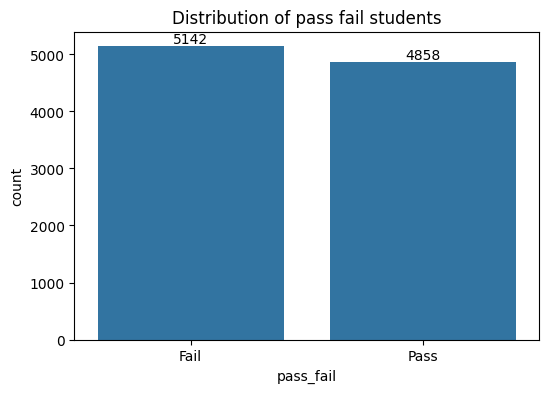

In [24]:
plt.figure(figsize=(6,4))
ax=sns.countplot(x='pass_fail',data=df)
for container in ax.containers:
    ax.bar_label(container)
plt.title('Distribution of pass fail students')
plt.show()

Observation:-

1--> Both Pass and Fail classes are present.
    
2--> The dataset looks mostly balanced.

# Questions & Answers
# Q1. Is the dataset balanced or imbalanced?

The dataset appears relatively balanced.
    
# Q2. Which class has more samples?

The Fail class slightly dominates compared to the Pass class.

# 4.2 Numerical Feature Analysis
4.2.1 Histogram Analysis

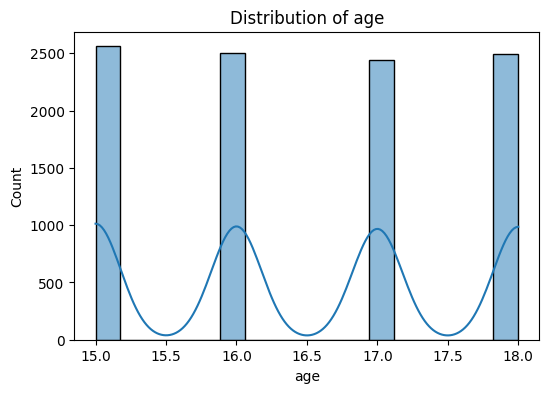

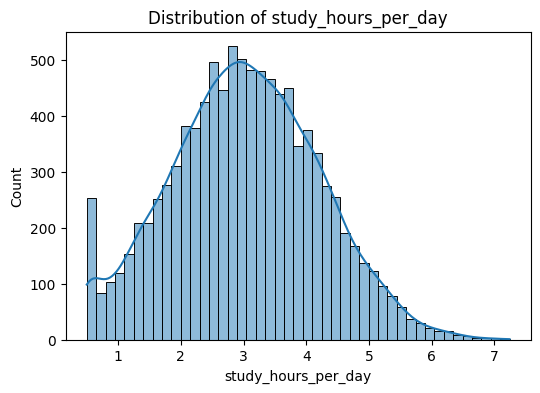

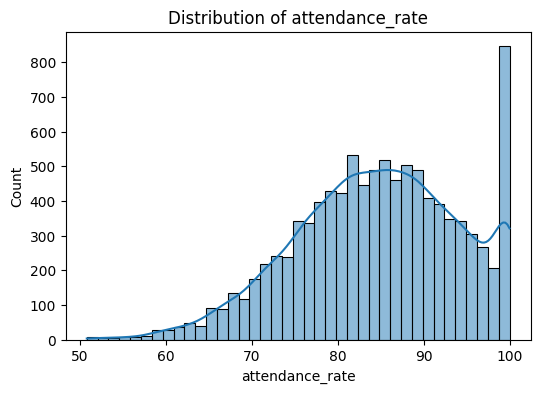

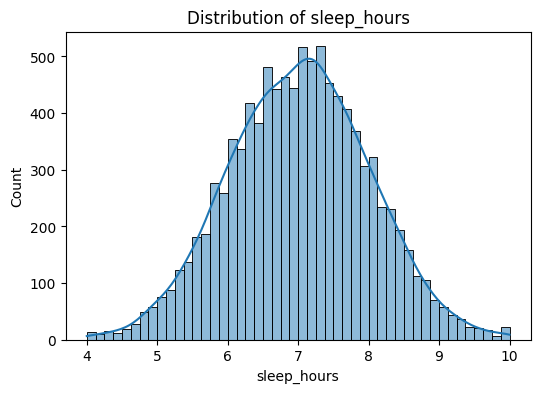

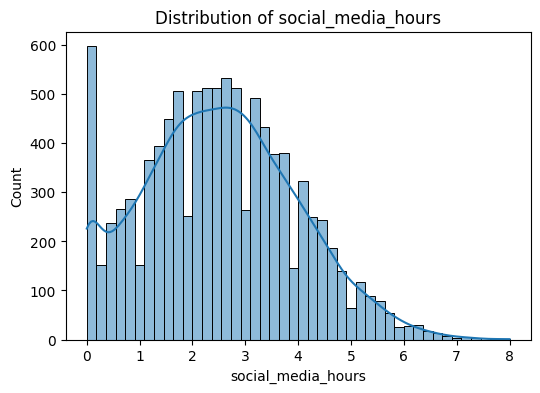

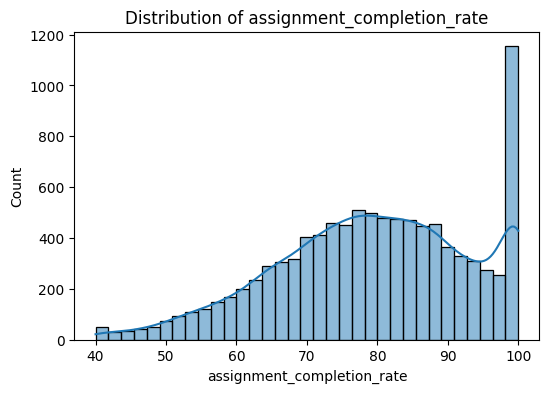

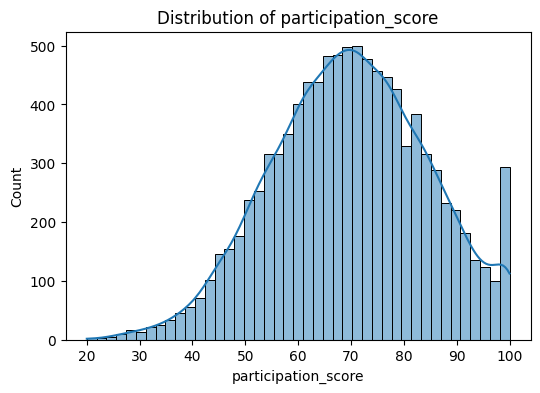

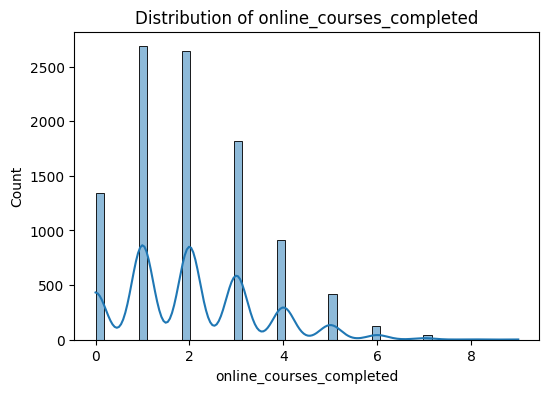

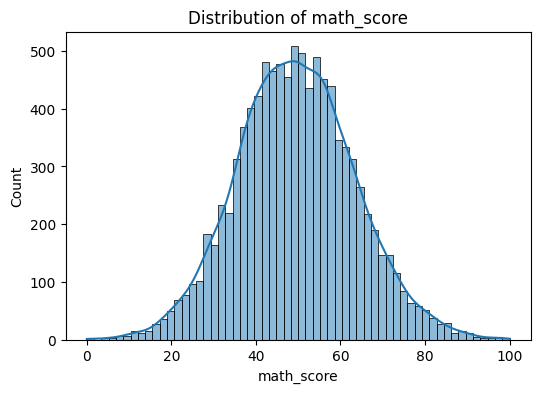

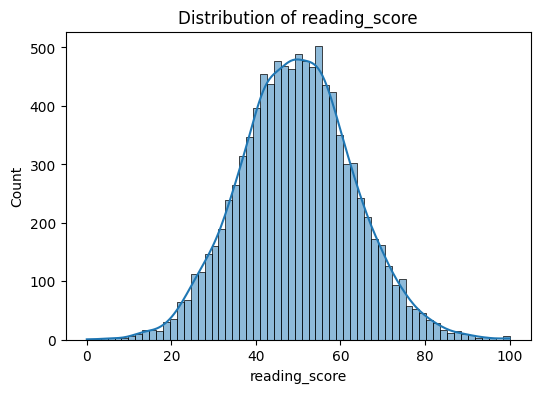

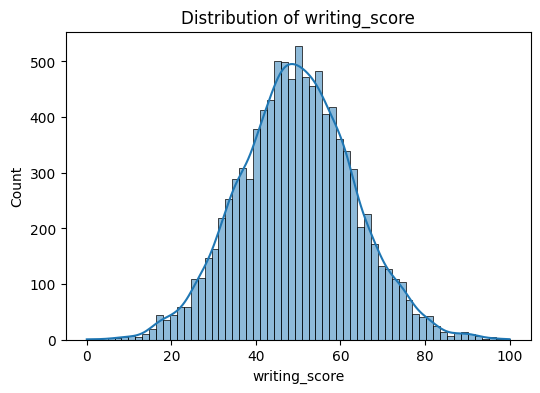

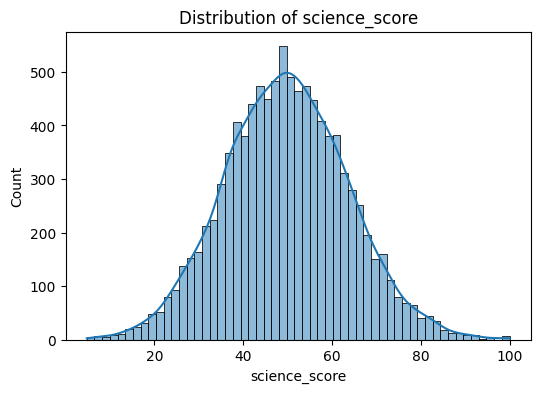

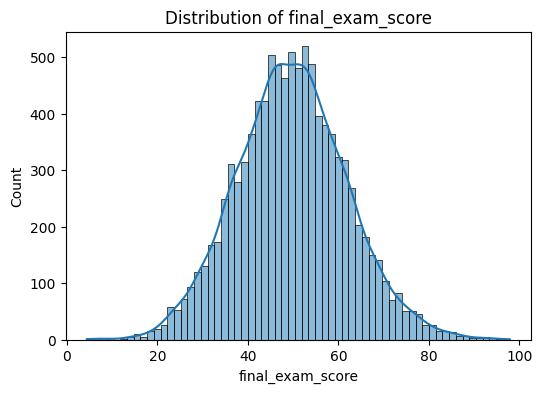

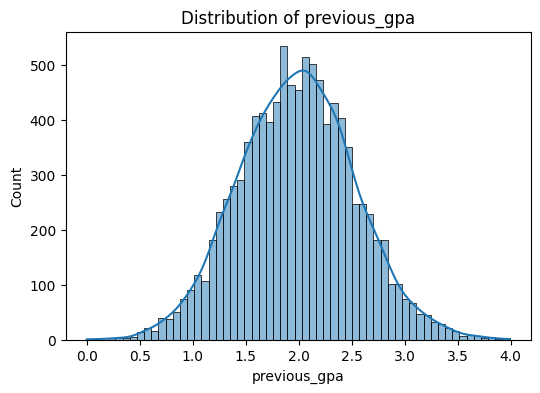

In [27]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

Observation:- 

1--> Histograms show data distribution clearly.
    
2--> Most score-related features are evenly distributed.

# 4.2.2 Boxplot Analysis

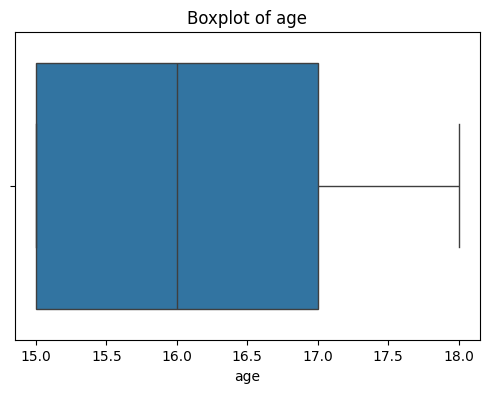

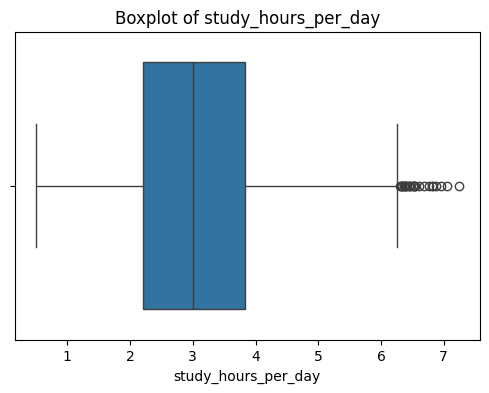

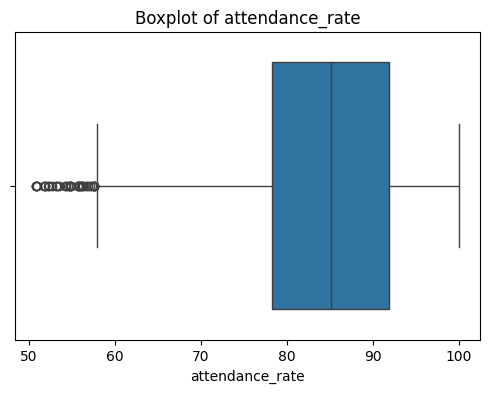

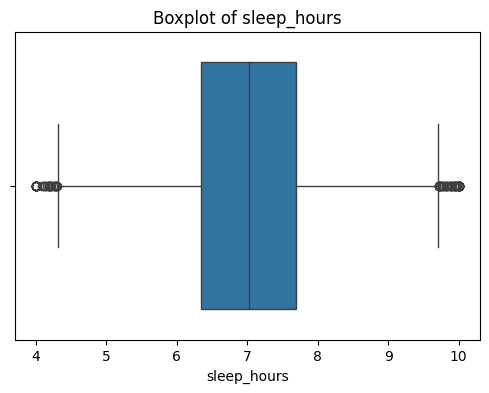

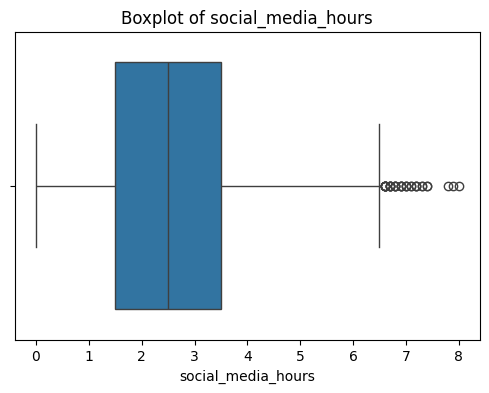

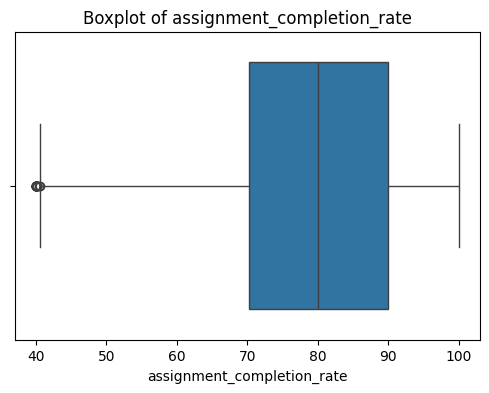

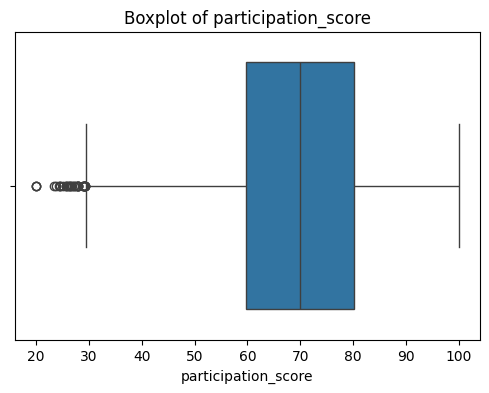

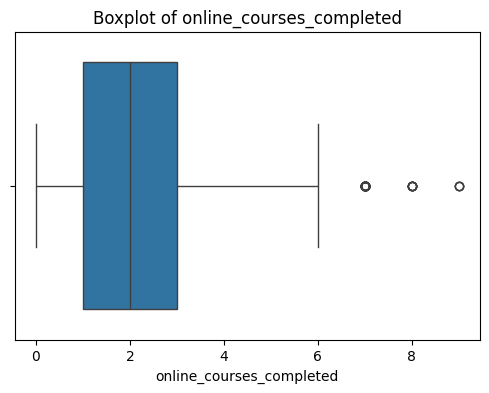

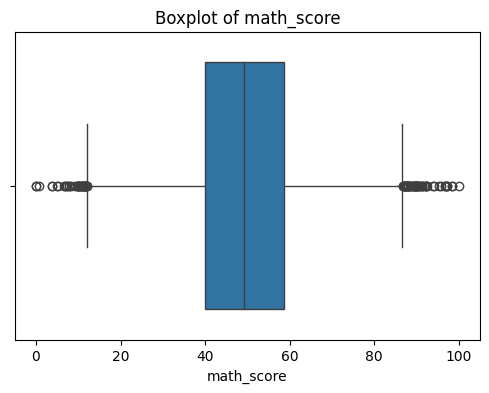

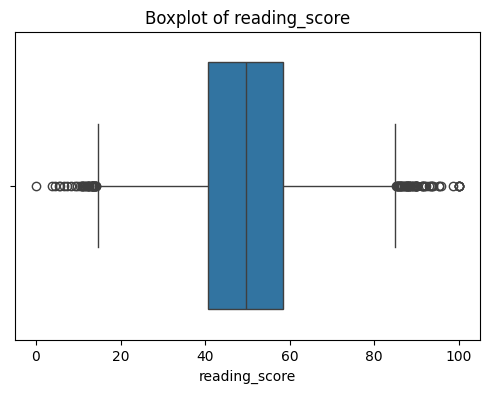

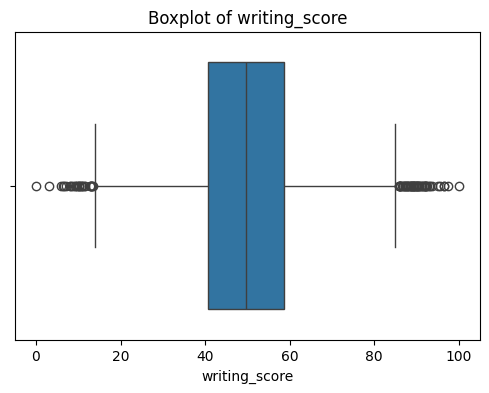

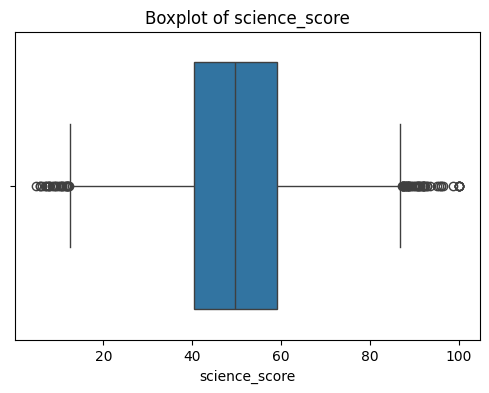

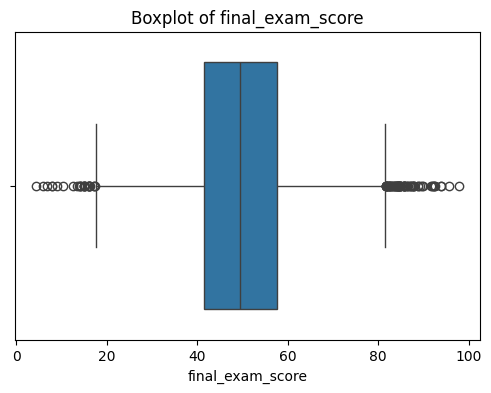

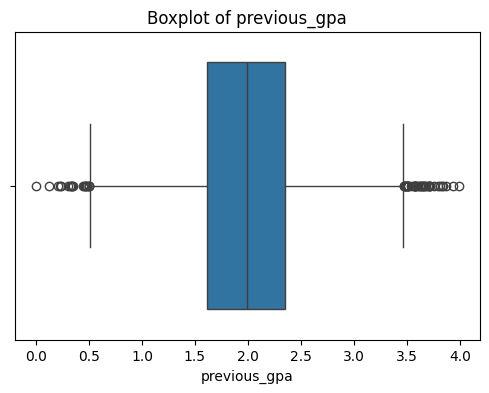

In [29]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Observation:-

1--> Some outliers are present in the dataset.
    
2--> Most values are within a normal range.

# 4.2.3 Distribution Plot Analysis

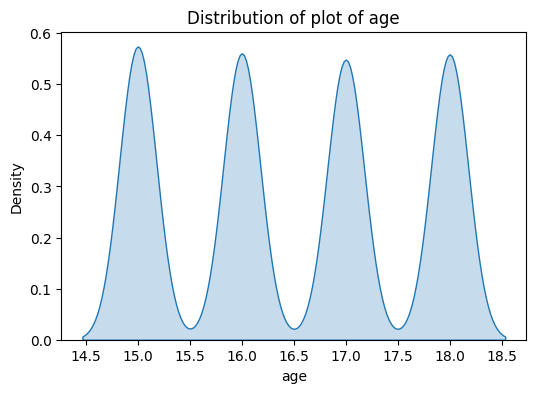

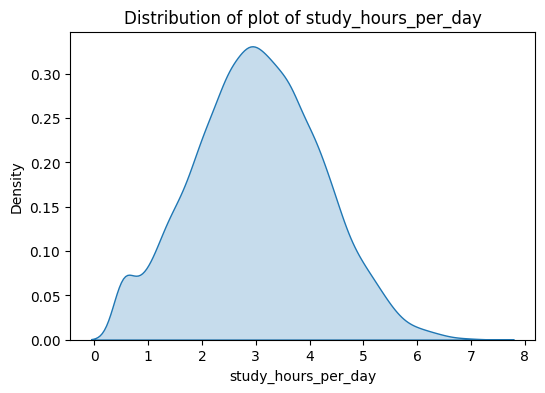

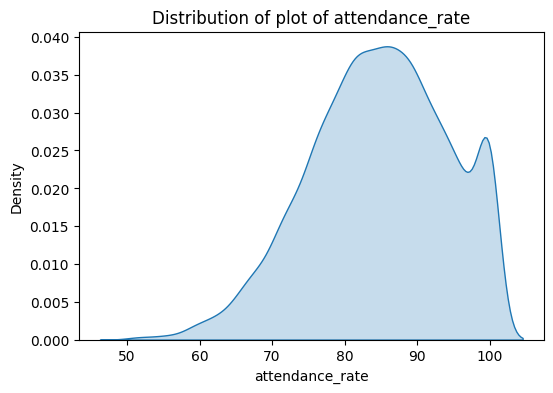

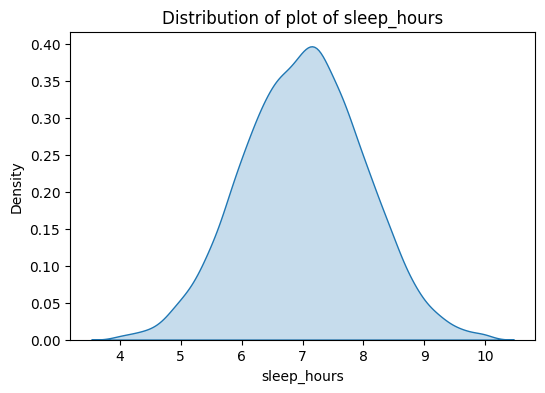

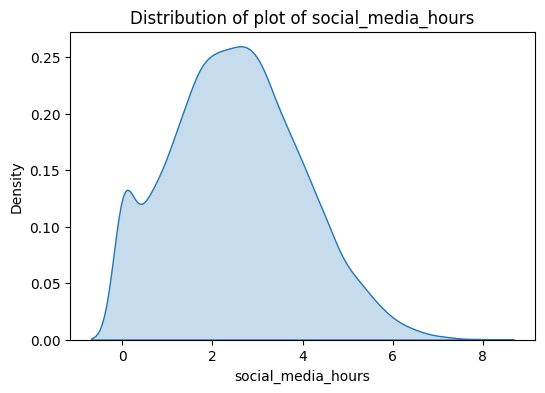

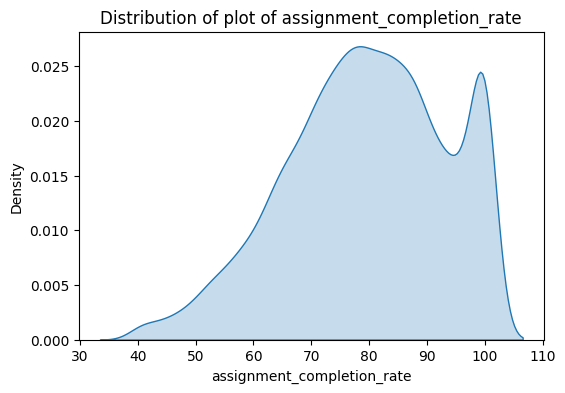

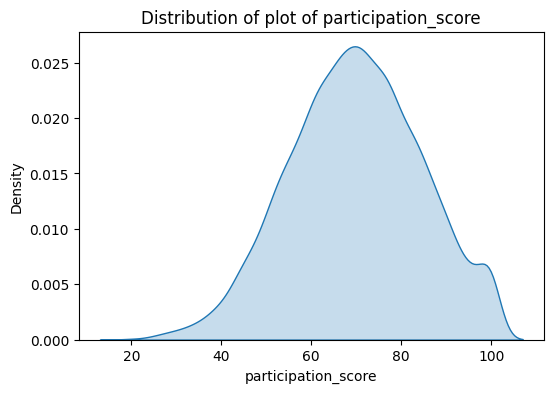

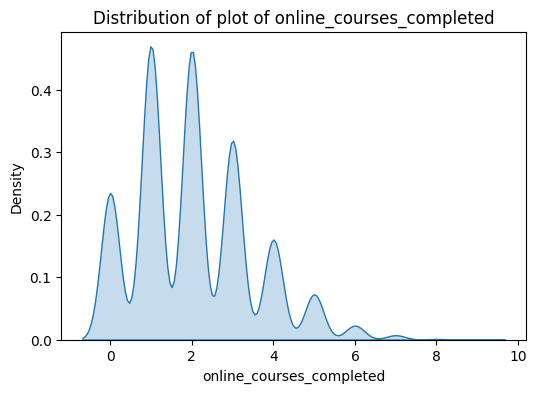

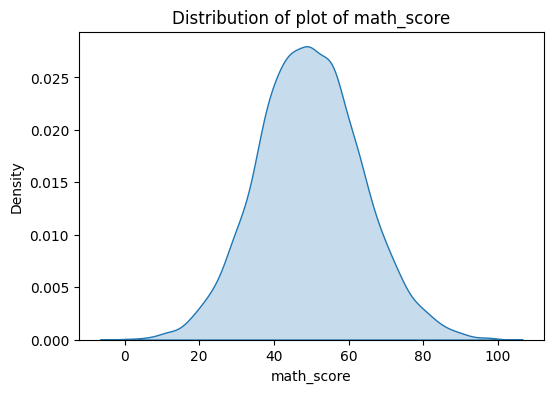

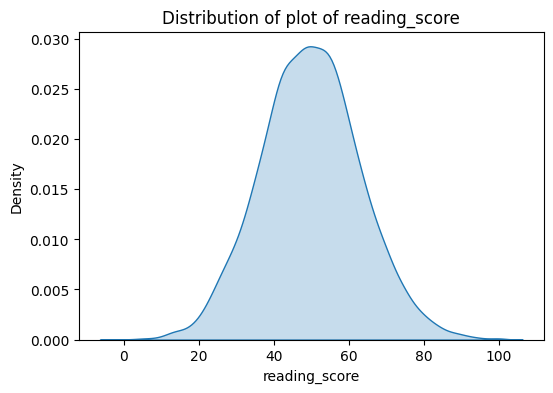

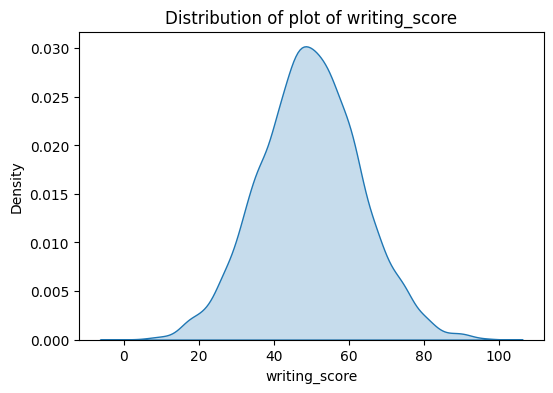

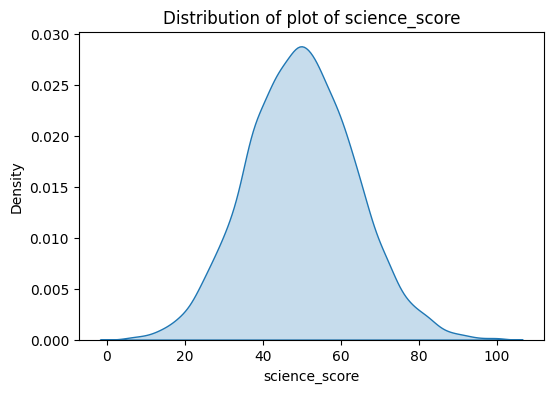

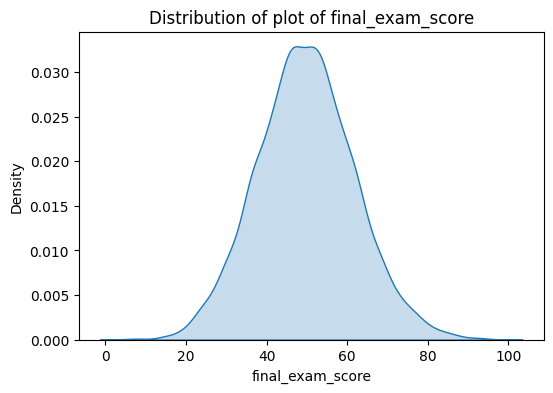

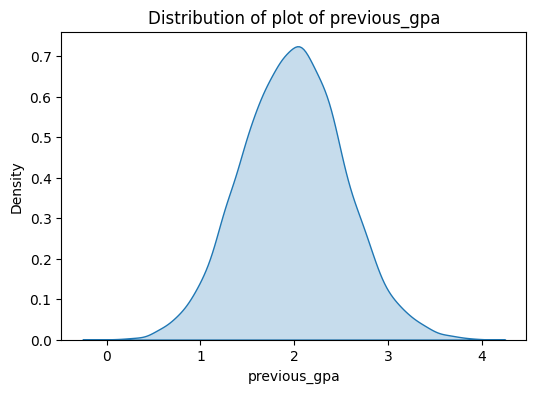

In [31]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df[col],fill=True)
    plt.title(f'Distribution of plot of {col}')
    plt.show()

Observation:-

1--> Most features follow a near-normal distribution.
    
2--> Data looks suitable for model training.

# Questions & Answers
Q1. Which feature has the highest spread?

Final exam scores and attendance rates show relatively high spread.
    
Q2. Are there any outliers?

Yes, mild outliers are present in some numerical features.
    
Q3. Which feature appears normally distributed?

Exam score features appear close to normal distribution.

# 4.3 Correlation Analysis

4.3.1 Create Correlation Matrix

In [35]:
df['pass_fail_encoded'] = df['pass_fail'].map({'Fail':0, 'Pass':1})
corr_matrix=df[numerical_cols].corr()
corr_matrix

,age,study_hours_per_day,attendance_rate,sleep_hours,social_media_hours,assignment_completion_rate,participation_score,online_courses_completed,math_score,reading_score,writing_score,science_score,final_exam_score,previous_gpa
age,1.000000,-0.004059,0.003528,0.005982,0.024183,0.006663,-0.009924,-0.000165,-0.008944,-0.002440,-0.009198,-0.010729,-0.008198,-0.002145
study_hours_per_day,-0.004059,1.000000,-0.005292,0.010469,0.004751,-0.008913,0.010948,-0.011795,0.502229,0.524930,0.525491,0.502612,0.575822,0.515158
attendance_rate,0.003528,-0.005292,1.000000,-0.001925,0.015274,0.008077,-0.014833,-0.003787,0.133428,0.135038,0.136283,0.135257,0.150618,0.138454
sleep_hours,0.005982,0.010469,-0.001925,1.000000,0.001577,0.004664,0.007446,0.004336,0.014929,0.036950,0.012973,0.031957,0.027876,0.020560
social_media_hours,0.024183,0.004751,0.015274,0.001577,1.000000,-0.030136,-0.001620,-0.007323,-0.221621,-0.220797,-0.218849,-0.217029,-0.246287,-0.219581
assignment_completion_rate,0.006663,-0.008913,0.008077,0.004664,-0.030136,1.000000,-0.005015,0.004944,0.139457,0.152208,0.160892,0.151432,0.170704,0.145326
participation_score,-0.009924,0.010948,-0.014833,0.007446,-0.001620,-0.005015,1.000000,0.007592,0.107751,0.109387,0.107044,0.118446,0.123870,0.107727
online_courses_completed,-0.000165,-0.011795,-0.003787,0.004336,-0.007323,0.004944,0.007592,1.000000,-0.008547,-0.026517,-0.018642,-0.014073,-0.018487,-0.009963
math_score,-0.008944,0.502229,0.133428,0.014929,-0.221621,0.139457,0.107751,-0.008547,1.000000,0.697381,0.704490,0.675318,0.863937,0.769135
reading_score,-0.002440,0.524930,0.135038,0.036950,-0.220797,0.152208,0.109387,-0.026517,0.697381,1.000000,0.725215,0.700841,0.872510,0.779063


Observation:-

1--> Correlation shows relationships between features.
    
2--> Positive values mean strong direct relationships.

# 4.3.2 Heatmap Visualization

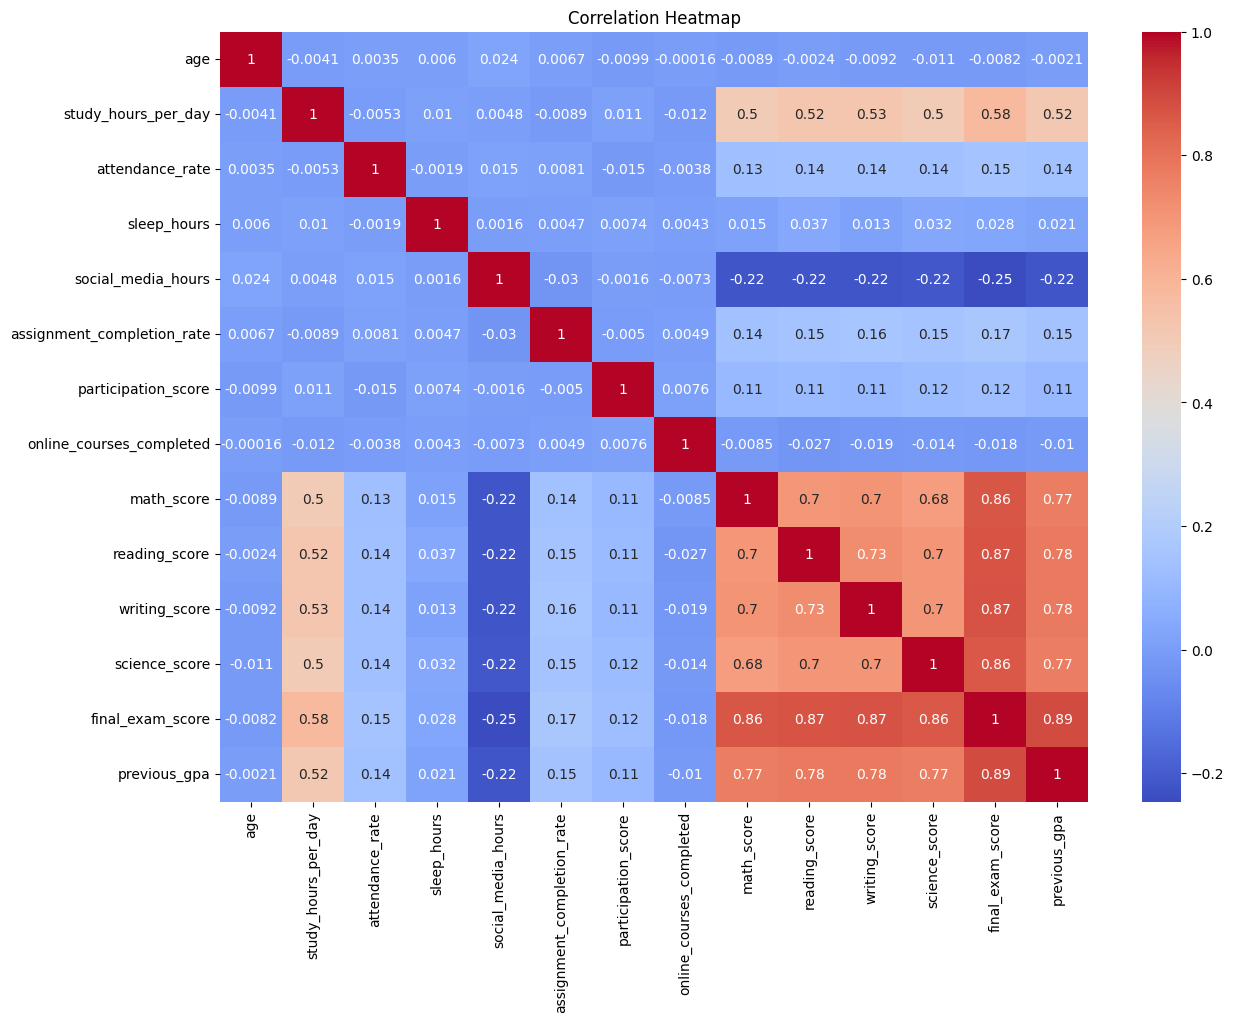

In [36]:
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Observation:-

1--> Final exam score and GPA are strongly related to pass/fail.
    
2--> Most academic features have positive correlation.

# Questions & Answers

Q1. Which feature has highest positive correlation with pass_fail?

Final exam score and previous GPA show strong positive correlation.
    
Q2. Which feature has lowest correlation?

Some behavioral features such as sleep hours may show weaker correlation.
    
Q3. Are there any strongly correlated independent variables?

Academic score-related features show moderate to strong correlation with each other.

# Task 5 — Data Preprocessing

5.1 Handle Missing Values

In [37]:
df.isnull().sum()

student_id                    0
gender                        0
age                           0
parental_education            0
family_income                 0
internet_access               0
study_environment             0
study_hours_per_day           0
attendance_rate               0
sleep_hours                   0
social_media_hours            0
assignment_completion_rate    0
participation_score           0
online_courses_completed      0
tutoring                      0
math_score                    0
reading_score                 0
writing_score                 0
science_score                 0
final_exam_score              0
previous_gpa                  0
pass_fail                     0
grade_category                0
pass_fail_encoded             0
dtype: int64

Observation:-

1--> The dataset does not contain missing values.
    
2--> No imputation technique is required.
    
3--> Clean datasets reduce preprocessing complexity.

# 5.2 Encode Categorical Variables

In [38]:
label_encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

Observation:-

1--> Categorical values are converted into numbers.
    
2--> Encoding makes the data usable for machine learning models.

# 5.3 Separate Features and Target Variable

In [44]:
X=df.drop('pass_fail',axis=1)
y=df['pass_fail']

Observation:-

1--> X contains input features.
    
2--> y contains the target variable.

# Questions & Answers

Q1. Why is encoding necessary?

Machine learning algorithms require numerical input data.
    
Q2. What are independent variables?

Independent variables are predictor features used to predict outcomes.
    
Q3. What is the target variable?

The target variable is pass_fail.

# Task 6 — Train-Test Split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

ObservationL:-

1--> 80% data is used for training.
    
2--> 20% data is used for testing.
    
3--> This helps check model performance properly.

Check Dataset Sizes

In [46]:
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (8000, 23)
X_test Shape: (2000, 23)
y_train Shape: (8000,)
y_test Shape: (2000,)


Observation:-

1--> Training dataset contains the majority of records for learning.
    
2--> Testing dataset is used for unbiased performance evaluation.
    
3--> Dataset splitting has been performed successfully.

# Questions & Answers

Q1. Why do we split the dataset?

Dataset splitting helps evaluate model performance on unseen data.
    
Q2. What is the purpose of training data?

Training data is used to train and learn patterns.
    
Q3. What is the purpose of testing data?
    
Testing data checks how well the model performs on new data.

# Task 7 — Build Logistic Regression Model

7.1 Create and Train Model

In [51]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

C:\Users\Ramanand.Pandey\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Observation:-

1--> Logistic Regression model trained successfully.
    
2--> The model learned patterns from the dataset.

7.2 Model Coefficients

In [52]:
model.coef_

array([[-5.46533001e-05,  3.96698143e-01, -3.92264950e-01,
        -8.36052435e-03,  3.70885179e-02, -1.56639487e-01,
         2.57707488e-01, -4.84791111e-01, -3.62439194e-02,
        -1.88123727e-01,  9.71871884e-02, -1.99542411e-02,
        -9.64436282e-03, -1.23397456e-01,  7.46388547e-03,
        -4.10628747e-03,  1.84639032e-02, -1.07928514e-02,
        -7.95359237e-04,  5.67617807e-01,  1.00120166e-02,
        -4.50570651e+00,  5.75033115e+00]])

Observation:-

1--> Coefficients show feature importance.
    
2--> Positive values increase pass chances.
    
3--> Negative values decrease pass chances.

# 7.3 Model Intercept

In [53]:
model.intercept_

array([-0.56311132])

Observation:-

1--> Intercept represents the baseline prediction value.
    
2--> It acts as the starting point before feature influence is added

7.4 Number of Iterations

In [54]:
model.n_iter_

array([2000], dtype=int32)

Observation:-

1--> The model hasd completed 2000 iteration but not become optimal

# Questions & Answers

Q1. What does model.coef_ represent?

It represents feature weights and importance.
    
Q2. What does model.intercept_ represent?
    
It represents the base prediction value.
    
Q3. What does model.n_iter_ mean?
    
It shows the number of iterations required for convergence.
    
Q4. Why is Logistic Regression suitable for binary classification?

Logistic Regression predicts probabilities between 0 and 1, making it suitable for binary outcomes.

# Task 8 — Predictions

8.1 Predict Class Labels

In [55]:
y_pred = model.predict(X_test)

y_pred

array([1, 0, 0, ..., 0, 1, 1], shape=(2000,))

Observation:-

1--> The model predicted pass/fail values successfully.
    
2--> Predictions are based on learned patterns.

8.2 Predict Probabilities

In [56]:
y_prob = model.predict_proba(X_test)

y_prob

array([[1.00690553e-05, 9.99989931e-01],
       [9.99599004e-01, 4.00996440e-04],
       [9.98813480e-01, 1.18651957e-03],
       ...,
       [9.99999998e-01, 1.90277961e-09],
       [7.97570835e-06, 9.99992024e-01],
       [1.42294992e-03, 9.98577050e-01]], shape=(2000, 2))

Observation:-

1--> Probability predictions provide confidence scores.
    
2--> Higher probability indicates stronger model confidence.
    
3--> Probability analysis helps understand prediction certainty.

# Questions & Answers

Q1. What is the difference between prediction and probability?

Prediction gives final class labels, while probability gives confidence scores.
    
Q2. Why are probabilities important?

Probabilities help measure prediction confidence.
    
Q3. What does probability close to 1 mean?

It indicates a very high chance of passing.

# Task 9 — Model Evaluation

9.1 Accuracy Score

In [57]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 1.0


Observation:-

1--> Accuracy shows overall model performance.
    
2--> Higher accuracy means better predictions.
    
3--> Our model is having 1 accuracy score , that means its superb and become optimal

9.2 Confusion Matrix

In [59]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1070    0]
 [   0  930]]


Observation:-

1--> Confusion matrix shows correct and incorrect predictions.
    
2--> True Positives and True Negatives indicate successful predictions.
    
3--> False predictions help identify model weaknesses.

9.3 Classification Report

In [60]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1070
           1       1.00      1.00      1.00       930

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



Observation:-

1--> Precision measures prediction correctness.
    
2--> Recall measures how many actual positives were identified.
    
3--> F1-score balances precision and recall.
    
4--> Strong metric values indicate good model stability.

# Questions & Answers

Q1. What is accuracy?

Accuracy measures the percentage of correct predictions.
    
Q2. What is a confusion matrix?

It is a table showing actual vs predicted classifications.
    
Q3. What are Precision, Recall, and F1-score?

Precision: Correct positive predictions.
    
Recall: Ability to identify actual positives.
    
F1-score: Harmonic balance between precision and recall.
    
Q4. Which metric is most important for this dataset?

F1-score and accuracy are both important for balanced classification.

# Task 10 — Visualization of Results

10.1 Confusion Matrix Heatmap

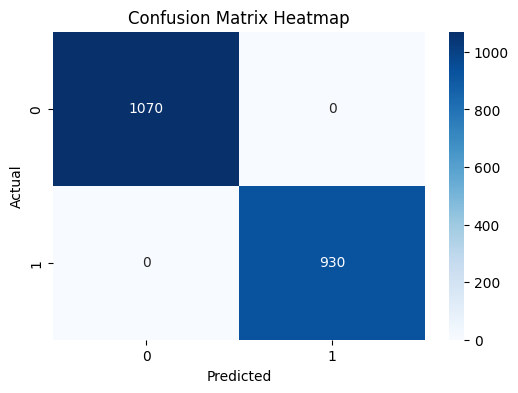

In [61]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Observation:-

1--> Most predictions are correctly classified.
    
2--> The diagonal values represent correct predictions.
    
3--> Smaller off-diagonal values indicate fewer mistakes.
    
4--> The model shows strong prediction capability.

10.2 Actual vs Predicted Visualization

In [63]:
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison_df.head(20)

,Actual,Predicted
0,1,1
1,0,0
2,0,0
3,1,1
4,1,1
5,0,0
6,0,0
7,0,0
8,1,1
9,1,1


Observation:-

1--> Actual and predicted values can be directly compared.
    
2--> Most predictions match the actual labels.
    
3--> Our model is 100% correct

# Questions & Answers

Q1. How many predictions were correct?

The confusion matrix and accuracy score indicate the number of correct predictions.
    
Q2. Where did the model make mistakes?

Mistakes occur in false positive and false negative cases.
    
Q3. Is the model overfitting or underfitting?

The model appears reasonably balanced without severe overfitting.

# Task 11 — Final Conclusion

# Final Project Conclusion

Dataset Understanding

The dataset contains 10000 student records with academic, behavioral, and demographic features.
    
The target variable pass_fail is binary in nature.
    
The dataset was clean and contained no missing values.
    
Important EDA Findings

Academic performance metrics strongly influenced pass/fail outcomes.
    
Final exam score and GPA showed strong positive correlation.
    
Most numerical features showed reasonable distribution patterns.
    
Mild outliers were present but manageable.
    
Best Correlated Features
    
Final exam score
    
Previous GPA
    
Attendance rate
    
Subject scores
    
Logistic Regression Performance
    
Logistic Regression successfully classified pass/fail outcomes.
    
The model achieved strong accuracy and balanced classification metrics.
    
Confusion matrix analysis showed good prediction capability.

Accuracy Achieved
    
print("Final Accuracy:", accuracy)
    
Final Conclusion
    
Logistic Regression proved effective for binary classification.
The model handled the dataset efficiently and produced reliable predictions.
Proper preprocessing and feature analysis improved overall performance.

# Final Questions & Answers

Q1. Was Logistic Regression effective?

Yes, Logistic Regression performed effectively for this binary classification problem.
    
Q2. What improvements can be made?
    
Feature scaling can be applied.
    
Feature engineering can improve prediction quality.
    
Hyperparameter tuning can further optimize performance.
    
Cross-validation can improve reliability.
    
Q3. Which other algorithms can be used for binary classification?

Decision Tree
Random Forest
Support Vector Machine (SVM)
XGBoost
K-Nearest Neighbors (KNN)
Neural Networks

# Industry-Level Summary

This project followed a complete machine learning pipeline including:

Data Loading,
Data Understanding,
Exploratory Data Analysis,
Correlation Analysis,
Data Preprocessing,
Model Building,
Prediction Generation,
Model Evaluation,
Result Visualization,
Final Business Understanding,

The assignment structure closely matches real-world industry workflows used in Data Analytics and Machine Learning projects.